The pandas data type stored in the 'normalized-losses' column is: object
The average of normalized losses is: 122.0


<ipython-input-4-720585a726c9>:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["normalized-losses"].replace(np.nan, avg_norm_loss, inplace=True)


The data type stored in the bore column is: object
The mean of values in the bore column: 3.3290499999999996


<ipython-input-4-720585a726c9>:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bore"].replace(np.nan, bore_avg, inplace=True)


The data type stored in the stroke column is: object
The mean of values in the stroke column: 3.2582999999999993


<ipython-input-4-720585a726c9>:68: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["stroke"].replace(np.nan, stroke_avg, inplace=True)


The mean of values in the horsepower column: 104.22277227722772


<ipython-input-4-720585a726c9>:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["horsepower"].replace(np.nan, horsepower_avg, inplace=True)


The mean of values in the peak-rpm column: 5125.990099009901


<ipython-input-4-720585a726c9>:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["peak-rpm"].replace(np.nan, peak_rpm_avg, inplace=True)
<ipython-input-4-720585a726c9>:95: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

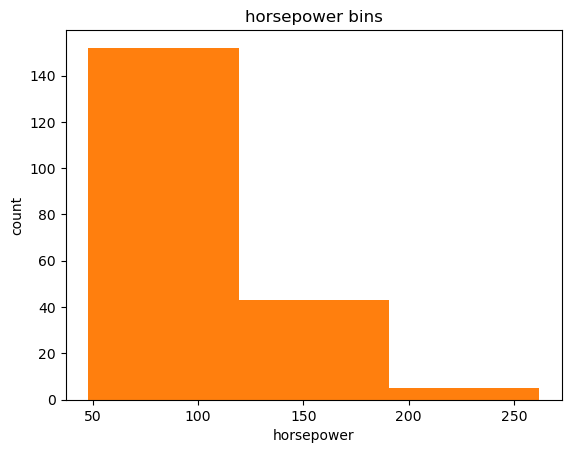

In [4]:
import pandas as pd
import numpy as np
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, 'wb') as f:
            f.write(await response.bytes())

file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"

await download(file_path, "usedcars.csv")

file_name = "usedcars.csv"

header = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

df = pd.read_csv(file_name)
df.columns = header
df.replace("?", np.nan, inplace=True)

#print(df.head(5))

missing_data = df.isnull()
#missing_data.head(5)

#for column in missing_data.columns.values.tolist():
#    print(missing_data[column].value_counts())
#    print("")

# dealing with missing values that exist in the "normalized-losses", "num-of-doors", "bore", "horsepower", "stroke", "peak-rpm", "price" cloumns respectively
# First, ascertaining the pandas data type stored in the "normalized-losses" column
norm_loss_type = df["normalized-losses"].dtype
print("The pandas data type stored in the 'normalized-losses' column is:", norm_loss_type)

avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("The average of normalized losses is:", avg_norm_loss)

df["normalized-losses"].replace(np.nan, avg_norm_loss, inplace=True)
#df.replace({"normalized-losses": avg_norm_loss}, inplace=True)
#df.head(10)

bore_data_type = df["bore"].dtype
print("The data type stored in the bore column is:", bore_data_type)

# Calculating the mean of the data values in the bore column
bore_avg = df["bore"].astype("float").mean(axis=0)
print("The mean of values in the bore column:", bore_avg)

# Replacing the missing values in the bore column with the average bore value

df["bore"].replace(np.nan, bore_avg, inplace=True)
#df.head(30)

stroke_data_type = df["stroke"].dtype
print("The data type stored in the stroke column is:", stroke_data_type)

# Calculating the mean of the data values in the stroke column
stroke_avg = df["stroke"].astype("float").mean(axis=0)
print("The mean of values in the stroke column:", stroke_avg)

# Replacing the missing values in the bore column with the average bore value

df["stroke"].replace(np.nan, stroke_avg, inplace=True)
#df.head(30)

# Calculating the mean of the data values in the horsepower column
horsepower_avg = df["horsepower"].astype("float").mean(axis=0)
print("The mean of values in the horsepower column:", horsepower_avg)

# Replacing the missing values in the horsepower column with the average horsepower value

df["horsepower"].replace(np.nan, horsepower_avg, inplace=True)
#df.head(10)

# Calculating the mean of the data values in the peak-rpm column

peak_rpm_avg = df["peak-rpm"].astype("float").mean(axis=0)
print("The mean of values in the peak-rpm column:", peak_rpm_avg)

# Replacing the missing values in the peak-rpm column with the average peak-rpm value

df["peak-rpm"].replace(np.nan, peak_rpm_avg, inplace=True)
#df.head(10)

# Replacing missing values in the 'num-of-doors' column with the most commonly occurring value
# Ascertaining the most commonly occurring value in the 'num-of-doors' column

df["num-of-doors"].value_counts()

df["num-of-doors"].replace(np.nan, "four", inplace=True)
df.head(10)
df["num-of-doors"].value_counts()

# Dropping all rows with Nan in the "price" column
df.dropna(subset=["price"], axis=0, inplace=True)

# Resetting
df.reset_index(drop=True, inplace=True)

# Converting the column data types into the proper formats

df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")

#df.dtypes

df["city-L/100km"] = 235/df["city-mpg"]
df["highway-L/100km"] = 235/df["highway-mpg"]

# Normalizing the 'length' and 'width' columns using 'simple feature scaling'
df["length"] = df["length"]/df["length"].max()
df["width"] = df["width"]/df["width"].max()

#print(df["length"])

df.head()

df["horsepower"] = df["horsepower"].astype("int", copy=True)

%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["horsepower"])

# setting x/y labels and plot title
plt.pyplot.ylabel("count")
plt.pyplot.xlabel("horsepower")
plt.pyplot.title("horsepower bin")

# binning the 'horsepower' column
bin = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
group_names = ["Low", "Medium", "High"]

#applying the 'cut' function to determine what each value of df["horsepower"] belongs to
df["horsepower-binned"] = pd.cut(df["horsepower"], bin, labels = group_names, include_lowest=True)
df[["horsepower", "horsepower-binned"]].head(20)

df["horsepower-binned"].value_counts()

# visualizing the bins
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot


# draw historgram of attribute "horsepower" with bins = 3
plt.pyplot.hist(df["horsepower"], bins = 3)

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

plt.pyplot.show()

#df["fuel-type"].value_counts()

# getting indicator variables and assigning them to data frame "dummy_variable_1"
dummy_variable_1 = pd.get_dummies(df["fuel-type"])
dummy_variable_1.head()

# renaming the column headings for greater clarity
dummy_variable_1.rename(columns={'gas' : 'fuel-type-gas', 'diesel' : 'fuel-type-diesel'}, inplace=True)
#dummy_variable_1.head()

# merging data frame "df" and "dummy_variable_1"

df = pd.concat([df, dummy_variable_1], axis=1)

#dropping the 'fuel-type' column from the original data frame 'df'
df.drop("fuel-type", axis=1, inplace=True)
df.head(10)

df.to_csv("clean_df.csv")
